In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random

# Part1

1. Problem Definition (ZDT1)

In [2]:
def zdt1_objectives(individual):
    """
    Calculates the two objective functions for the ZDT1 problem.
    ZDT1 is a two-objective minimization problem.
    The Pareto front is given by f2 = 1 - sqrt(f1) for f1 in [0, 1].
    """
    n_vars = len(individual)
    f1 = individual[0]

    g = 1.0 + (9.0 / (n_vars - 1)) * np.sum(individual[1:])
    f2 = g * (1.0 - np.sqrt(f1 / g))
    
    return np.array([f1, f2])

2. NSGA-II Core Functions

In [3]:
def dominates(obj1, obj2):
    """
    Checks if objective set obj1 dominates obj2.
    For minimization problems, obj1 dominates obj2 if obj1 is less than or equal to obj2
    in all objectives and strictly less than in at least one objective.
    """
    # Check if obj1 is less than or equal to obj2 in all objectives
    #TODO
    all_le = np.all(obj1 <= obj2)
    # Check if obj1 is strictly less than obj2 in at least one objective
    #TODO
    any_lt = np.any(obj1 < obj2)

    return all_le and any_lt

In [4]:
def non_dominated_sort(population_objectives):
    """
    Performs non-dominated sorting on a population's objectives.
    Returns a list of fronts, where each front contains indices of individuals.
    """
    num_individuals = len(population_objectives)
    # n_p: number of individuals that dominate p
    # S_p: set of individuals dominated by p
    #TODO
    n = [0] * num_individuals  # Domination count for each individual
    S = [[] for _ in range(num_individuals)]  # Set of individuals dominated by each individual

    
    fronts = [[]] # F_1, F_2, ...
    
    for p in range(num_individuals):
        for q in range(num_individuals):
            #TODO
            if dominates(population_objectives[p], population_objectives[q]):
                S[p].append(q)
            elif dominates(population_objectives[q], population_objectives[p]):
                n[p] += 1
        if n[p] == 0:
            fronts[0].append(p)
    
    i = 0
    while len(fronts[i]) > 0:
        Q = [] # Next front
        #TODO
        for p in fronts[i]:
            for q in S[p]:
                n[q] -= 1
                if n[q] == 0:
                    Q.append(q)
        i += 1
        fronts.append(Q)
            
    return fronts[:-1] # Remove the last empty front

In [5]:
def calculate_crowding_distance(front_indices, population_objectives):
    """
    Calculates the crowding distance for individuals in a given front.
    Higher crowding distance is better (more diverse).
    """
    if not front_indices:
        return {}

    distances = {idx: 0.0 for idx in front_indices}
    num_objectives = population_objectives.shape[1]

    # Convert front indices to their actual objective values
    front_objs = population_objectives[front_indices]

    for m in range(num_objectives):
        # Sort the front by the m-th objective
        #TODO
        # Get indices of front members sorted by the current objective
        sorted_indices_on_obj = np.argsort(front_objs[:, m])
        # Map back to original population indices
        sorted_front_indices = [front_indices[i] for i in sorted_indices_on_obj]
        
        # Assign infinite distance to boundary points
        #TODO
        distances[sorted_front_indices[0]] = float('inf')
        distances[sorted_front_indices[-1]] = float('inf')

        # Calculate range for normalization
        #TODO
        # Get objective values for the boundary points
        obj_max = population_objectives[sorted_front_indices[-1]][m]
        obj_min = population_objectives[sorted_front_indices[0]][m]
        # Avoid division by zero if all objectives are the same
        if obj_max == obj_min:
            continue
        
        # Calculate distance for intermediate points
        #TODO
        for j in range(1, len(sorted_front_indices) - 1):
            idx = sorted_front_indices[j]
            prev_idx = sorted_front_indices[j - 1]
            next_idx = sorted_front_indices[j + 1]
            
        # Add the normalized distance between neighbors
        distances[idx] += (population_objectives[next_idx][m] - population_objectives[prev_idx][m]) / (obj_max - obj_min)
        
    return distances

In [6]:
def tournament_selection(population, population_objectives, crowding_distances, k=2):
    """
    Performs tournament selection based on rank and then crowding distance.
    """
    selected = []
    for _ in range(len(population)):
        # Select k random individuals
        competitors_indices = random.sample(range(len(population)), k)
        
        winner_idx = competitors_indices[0]
        for i in range(1, k):
            #TODO
            competitor_idx = competitors_indices[i]
            # Compare based on rank, then crowding distance
            # A lower rank is better
            if population[competitor_idx]['rank'] < population[winner_idx]['rank']:
                winner_idx = competitor_idx
            # If ranks are equal, a higher crowding distance is better
            elif (population[competitor_idx]['rank'] == population[winner_idx]['rank'] and
                    crowding_distances[competitor_idx] > crowding_distances[winner_idx]):
                winner_idx = competitor_idx
            selected.append(population[winner_idx])
    return selected

In [7]:
def sbx_crossover(parent1, parent2, prob_crossover, eta_c):
    """
    Simulated Binary Crossover (SBX) for real-coded GAs.
    Creates two offspring from two parents.
    """
    offspring1 = np.copy(parent1)
    offspring2 = np.copy(parent2)
    
    if random.random() <= prob_crossover:
        for i in range(len(parent1)):
            if random.random() <= 0.5: # Apply crossover to this variable
                #TODO
                u = random.random()
                if u <= 0.5:
                    beta = (2 * u) ** (1.0 / (eta_c + 1.0))
                else:
                    beta = (1.0 / (2.0 * (1.0 - u))) ** (1.0 / (eta_c + 1.0))

                # Calculate offspring values
                offspring1[i] = 0.5 * ((1 + beta) * parent1[i] + (1 - beta) * parent2[i])
                offspring2[i] = 0.5 * ((1 - beta) * parent1[i] + (1 + beta) * parent2[i])

                # Ensure offspring are within bounds [0, 1]
                offspring1[i] = np.clip(offspring1[i], 0.0, 1.0)
                offspring2[i] = np.clip(offspring2[i], 0.0, 1.0)
                
    return offspring1, offspring2

In [8]:
def polynomial_mutation(individual, prob_mutation, eta_m):
    """
    Polynomial Mutation for real-coded GAs.
    Applies a small perturbation to each variable with a certain probability.
    """
    mutated_individual = np.copy(individual)
    
    for i in range(len(individual)):
        if random.random() <= prob_mutation:
            #TODO
            r = random.random()
            if r < 0.5:
                delta = (2 * r) ** (1.0 / (eta_m + 1.0)) - 1.0
            else:
                delta = 1.0 - (2 * (1 - r)) ** (1.0 / (eta_m + 1.0))

            mutated_individual[i] += delta
            # Ensure the mutated value is within bounds [0, 1]
            mutated_individual[i] = np.clip(mutated_individual[i], 0.0, 1.0)
            
    return mutated_individual

3. NSGA-II Algorithm

In [ ]:
def nsga2(
    n_individuals,
    n_generations,
    n_vars,
    prob_crossover,
    prob_mutation,
    eta_c, # Crossover distribution index
    eta_m, # Mutation distribution index
    objective_function
):
    """
    Main NSGA-II algorithm.
    """
    # Initialize population
    population = []
    for _ in range(n_individuals):
        individual = np.random.rand(n_vars) # Variables between 0 and 1
        population.append({'individual': individual, 'objectives': objective_function(individual)})

    print(f"Starting NSGA-II with {n_individuals} individuals for {n_generations} generations...")

    for gen in range(n_generations):
        # Evaluate objectives for current population
        #TODO
        current_objectives = np.array([ind['objectives'] for ind in population])
        # Perform non-dominated sorting
        #TODO
        fronts = non_dominated_sort(current_objectives)
        # Calculate crowding distance for each front and assign ranks
        all_crowding_distances = {}
        for i, front in enumerate(fronts):
            crowding_distances_front = calculate_crowding_distance(front, current_objectives)
            #TODO
            for idx in crowding_distances_front:
                population[idx]['rank'] = i
                population[idx]['crowding_distance'] = crowding_distances_front[idx]
                all_crowding_distances.update(crowding_distances_front)

        # Generate offspring using selection, crossover, and mutation
        offspring_population = []
        selected_individuals = tournament_selection(population, current_objectives, all_crowding_distances)
        
        # Pair up selected individuals for crossover
        random.shuffle(selected_individuals)
        for i in range(0, len(selected_individuals), 2):
            #TODO
            if i + 1 >= len(selected_individuals):
                break # Avoid index out of bounds if odd number of individuals

            parent1_dict = selected_individuals[i]
            parent2_dict = selected_individuals[i+1]

            parent1 = parent1_dict['individual']
            parent2 = parent2_dict['individual']

            offspring1, offspring2 = sbx_crossover(parent1, parent2, prob_crossover, eta_c)

            mutated_offspring1 = polynomial_mutation(offspring1, prob_mutation, eta_m)
            mutated_offspring2 = polynomial_mutation(offspring2, prob_mutation, eta_m)

            offspring_population.append({'individual': mutated_offspring1, 'objectives': objective_function(mutated_offspring1)})
            offspring_population.append({'individual': mutated_offspring2, 'objectives': objective_function(mutated_offspring2)})

        # Combine parent and offspring populations
        #TODO
        combined_population = population + offspring_population

        # Perform non-dominated sorting on the combined population
        #TODO
        combined_objectives = np.array([ind['objectives'] for ind in combined_population])
        combined_fronts = non_dominated_sort(combined_objectives)
        # Environmental Selection: Select the next generation
        new_population = []
        current_pop_size = 0
        
        for i, front in enumerate(combined_fronts):
            if current_pop_size + len(front) <= n_individuals:
                # If the entire front fits, add it
                for idx in front:
                    new_population.append({
                        'individual': combined_population[idx]['individual'],
                        'objectives': combined_population[idx]['objectives'],
                        'rank': i,
                        'crowding_distance': calculate_crowding_distance(front, combined_objectives).get(idx, 0.0)
                    })
                current_pop_size += len(front)
            else:
                # If the front doesn't entirely fit, sort by crowding distance and take the best
                remaining_capacity = n_individuals - current_pop_size
                
                # Calculate crowding distances for this specific front
                front_crowding_distances = calculate_crowding_distance(front, combined_objectives)
                
                # Sort individuals in the front by crowding distance in descending order
                sorted_front_by_crowding = sorted(front, key=lambda idx: front_crowding_distances.get(idx, 0.0), reverse=True)
                
                for j in range(remaining_capacity):
                    idx = sorted_front_by_crowding[j]
                    new_population.append({
                        'individual': combined_population[idx]['individual'],
                        'objectives': combined_population[idx]['objectives'],
                        'rank': i,
                        'crowding_distance': front_crowding_distances.get(idx, 0.0)
                    })
                current_pop_size += remaining_capacity
                break # Population size reached

        population = new_population
        
        if (gen + 1) % 10 == 0 or gen == n_generations - 1:
            print(f"Generation {gen + 1}/{n_generations} completed.")

    print("NSGA-II algorithm finished.")
    return population

4. Visualization 

In [10]:
def plot_pareto_front(final_population, title="NSGA-II Pareto Front (ZDT1)"):
    """
    Plots the objective values of the final population.
    Also plots the true Pareto front for ZDT1 for comparison.
    """
    objectives = np.array([ind['objectives'] for ind in final_population])
    f1_values = objectives[:, 0]
    f2_values = objectives[:, 1]

    plt.figure(figsize=(10, 7))
    plt.scatter(f1_values, f2_values, s=50, edgecolors='k', alpha=0.7, label='NSGA-II Solutions')

    # Plot true Pareto front for ZDT1
    true_f1 = np.linspace(0, 1, 100)
    true_f2 = 1 - np.sqrt(true_f1)
    plt.plot(true_f1, true_f2, color='red', linestyle='--', label='True Pareto Front')

    plt.title(title)
    plt.xlabel("Objective 1 ($f_1$)")
    plt.ylabel("Objective 2 ($f_2$)")
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()
    plt.show()

Main Execution

Starting NSGA-II with 100 individuals for 200 generations...
Generation 10/200 completed.
Generation 20/200 completed.
Generation 30/200 completed.
Generation 40/200 completed.
Generation 50/200 completed.
Generation 60/200 completed.
Generation 70/200 completed.
Generation 80/200 completed.
Generation 90/200 completed.
Generation 100/200 completed.
Generation 110/200 completed.
Generation 120/200 completed.
Generation 130/200 completed.
Generation 140/200 completed.
Generation 150/200 completed.
Generation 160/200 completed.
Generation 170/200 completed.
Generation 180/200 completed.
Generation 190/200 completed.
Generation 200/200 completed.
NSGA-II algorithm finished.


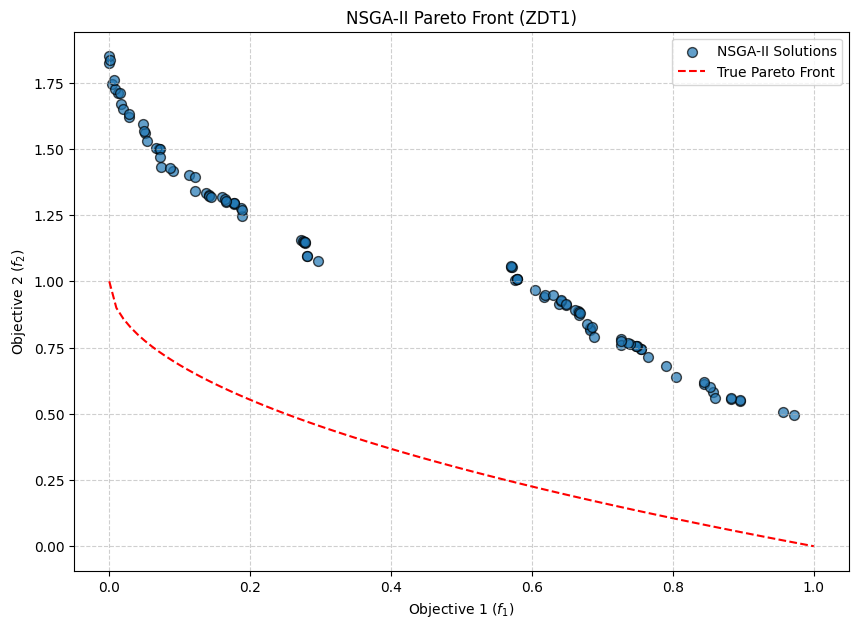


First 5 individuals in the final population (individual, objectives, rank, crowding_distance):
Individual 1:
  Variables: [8.44420327e-01 1.39799116e-05 3.35995722e-01 1.20390091e-01
 2.71847730e-02]...
  Objectives: [0.84442033 0.61055726]
  Rank: 0
  Crowding Distance: 0.0000
Individual 2:
  Variables: [7.54157203e-01 1.45425928e-04 5.15579763e-01 3.37600663e-02
 1.27569662e-01]...
  Objectives: [0.7541572 0.7454349]
  Rank: 0
  Crowding Distance: 0.0000
Individual 3:
  Variables: [0.57013226 0.0016476  0.13873328 0.20947032 0.13702873]...
  Objectives: [0.57013226 1.05448317]
  Rank: 0
  Crowding Distance: 0.0000
Individual 4:
  Variables: [0.13724294 0.         0.13065583 0.00703154 0.00123048]...
  Objectives: [0.13724294 1.33408146]
  Rank: 0
  Crowding Distance: 0.0000
Individual 5:
  Variables: [0.64899167 0.00563382 0.50361024 0.01997815 0.14345994]...
  Objectives: [0.64899167 0.91019061]
  Rank: 0
  Crowding Distance: 0.0000


In [12]:
if __name__ == "__main__":
    # Parameters for NSGA-II
    POPULATION_SIZE = 100 # Number of individuals in the population
    NUM_GENERATIONS = 200 # Number of generations to evolve
    NUM_VARIABLES = 30    # Number of decision variables for ZDT1
    
    # Genetic operator probabilities and distribution indices
    PROB_CROSSOVER = 0.9  # Probability of crossover
    PROB_MUTATION = 1.0 / NUM_VARIABLES # Probability of mutation per variable
    ETA_C = 20            # Distribution index for SBX crossover (higher -> closer to parents)
    ETA_M = 20            # Distribution index for Polynomial Mutation (higher -> smaller changes)

    # Run the NSGA-II algorithm
    final_population = nsga2(
        n_individuals=POPULATION_SIZE,
        n_generations=NUM_GENERATIONS,
        n_vars=NUM_VARIABLES,
        prob_crossover=PROB_CROSSOVER,
        prob_mutation=PROB_MUTATION,
        eta_c=ETA_C,
        eta_m=ETA_M,
        objective_function=zdt1_objectives
    )

    # Extract objectives from the final population
    final_objectives = np.array([ind['objectives'] for ind in final_population])

    # Plot the results
    plot_pareto_front(final_population)
    
    print("\nFirst 5 individuals in the final population (individual, objectives, rank, crowding_distance):")
    for i in range(min(5, len(final_population))):
        print(f"Individual {i+1}:")
        print(f"  Variables: {final_population[i]['individual'][:5]}...") # Print first 5 for brevity
        print(f"  Objectives: {final_population[i]['objectives']}")
        print(f"  Rank: {final_population[i]['rank']}")
        print(f"  Crowding Distance: {final_population[i]['crowding_distance']:.4f}")

# Part2

1. Prompt Class Definition

In [43]:
class Prompt:
    """
    Represents a prompt individual in the evolutionary algorithm.
    Includes the prompt string, its objective values, and constraint violation details.
    """
    def __init__(self, text):
        self.text = text
        self.objectives = np.array([0.0, 0.0, 0.0]) # e.g., Clarity, Conciseness (inverted), Relevance
        self.violations = {} # Dictionary of {constraint_name: violation_value}
        self.total_violation = 0.0 # Sum of all constraint violations
        self.rank = 0 # Pareto rank (lower is better)
        self.crowding_distance = 0.0 # Crowding distance (higher is better)

    def __repr__(self):
        return (f"Prompt(text='{self.text[:50]}...', "
                f"Objs={np.round(self.objectives, 2)}, "
                f"Viol={self.total_violation:.2f}, "
                f"Rank={self.rank}, CD={self.crowding_distance:.2f})")

2. Mock LLM Interactions

In a real application, these would be actual API calls to an LLM.

In [44]:
def mock_generate_initial_prompt():
    """
    Mocks generating a random initial prompt, now with a higher chance of being
    closer to feasible constraints.
    """
    starters = [
        "Explain the fundamental concepts of",
        "Describe in detail how",
        "Summarize the key principles of",
        "Analyze the impact of"
    ]
    topics = [
        "artificial intelligence and its applications.",
        "quantum computing and its potential.",
        "sustainable energy solutions for the future.",
        "machine learning algorithms and their uses in data science."
    ]
    # Combine to make them longer and more likely to contain keywords
    return f"{random.choice(starters)} {random.choice(topics)}"

In [45]:
def mock_mutate_prompt(prompt_text):
    """
    Mocks mutating a prompt.
    Now includes a specific mutation to add required keywords if missing.
    """
    words = prompt_text.split()
    if not words:
        return ""

    mutation_types = ["add_detail", "rephrase_word", "remove_word", "add_keyword"]
    mutation_type = random.choice(mutation_types)

    if mutation_type == "add_detail" and len(words) < 35: # Increased max length for detail addition
        details = [" in a comprehensive manner.", " with real-world examples and implications.", " concisely and clearly for a general audience.", " focusing on its practical applications."]
        return prompt_text.replace(".", f"{random.choice(details)}.") if "." in prompt_text else prompt_text + random.choice(details)
    elif mutation_type == "rephrase_word" and len(words) > 5: # Ensure enough words to rephrase
        idx = random.randint(1, len(words) - 2) # Avoid first/last word
        word_to_replace = words[idx]
        synonyms = {
            "explain": "elucidate", "describe": "illustrate", "story": "narrative",
            "concept": "idea", "summarize": "condense", "analyze": "evaluate"
        }
        if word_to_replace.lower() in synonyms:
            words[idx] = synonyms[word_to_replace.lower()]
            return " ".join(words)
    elif mutation_type == "remove_word" and len(words) > 15: # Only remove if prompt is reasonably long
        idx = random.randint(1, len(words) - 2)
        del words[idx]
        return " ".join(words)
    elif mutation_type == "add_keyword":
        # Attempt to add a missing required keyword
        required_keywords = ["explain", "AI", "concept", "machine learning"] # Example keywords
        missing_keywords = [kw for kw in required_keywords if kw.lower() not in prompt_text.lower()]
        if missing_keywords:
            keyword_to_add = random.choice(missing_keywords)
            # Try to insert it naturally
            if "about" in words:
                idx = words.index("about")
                words.insert(idx + 1, keyword_to_add)
            elif "of" in words:
                idx = words.index("of")
                words.insert(idx + 1, keyword_to_add)
            else:
                words.insert(0, keyword_to_add + ",") # Prepend if no good insertion point
            return " ".join(words)
    
    return prompt_text # No mutation happened or condition not met


In [46]:
def mock_crossover_prompts(prompt1_text, prompt2_text):
    """
    Mocks crossover between two prompts.
    Simple concatenation/segment swapping for demonstration.
    In reality, an LLM would intelligently combine ideas.
    """
    words1 = prompt1_text.split()
    words2 = prompt2_text.split()

    if not words1 or not words2:
        return prompt1_text, prompt2_text

    # Simple one-point crossover
    crossover_point1 = random.randint(1, len(words1) - 1)
    crossover_point2 = random.randint(1, len(words2) - 1)

    offspring1_words = words1[:crossover_point1] + words2[crossover_point2:]
    offspring2_words = words2[:crossover_point2] + words1[crossover_point1:]

    return " ".join(offspring1_words), " ".join(offspring2_words)

In [47]:
def mock_evaluate_objectives(prompt_text, llm_response_text):
    """
    Mocks evaluating objectives based on prompt and (mock) LLM response.
    In reality, this would involve NLP metrics or another LLM.
    Objectives: Clarity (max), Conciseness (min, so 1/len), Relevance (max)
    """
    # Mock Clarity: Longer prompts might be clearer, but too long is bad.
    # Adjusted range to better fit new prompt lengths
    clarity = max(0, 10 - abs(len(prompt_text.split()) - 25) / 2) # Max at 25 words, decreases away
    
    # Mock Conciseness (of response): Shorter response is better (minimize objective)
    conciseness = len(llm_response_text) / 100.0 # Normalize for a reasonable range

    # Mock Relevance: Based on presence of certain "keywords" in response
    expected_keywords = ["AI", "machine learning", "data", "algorithm", "solution", "impact"]
    relevance_score = sum(1 for kw in expected_keywords if kw.lower() in llm_response_text.lower()) * 2.0
    
    return np.array([clarity, conciseness, relevance_score])

In [48]:
def mock_check_constraints(prompt_text, llm_response_text, constraints_criteria):
    """
    Mocks checking constraints.
    Returns a dictionary of {constraint_name: violation_value}.
    Violation_value > 0 means violation.
    """
    violations = {}

    # Word Count Constraint (Prompt)
    min_words = constraints_criteria.get("min_words", 10)
    max_words = constraints_criteria.get("max_words", 50)
    prompt_word_count = len(prompt_text.split())
    if prompt_word_count < min_words:
        violations["word_count_min"] = min_words - prompt_word_count
    elif prompt_word_count > max_words:
        violations["word_count_max"] = prompt_word_count - max_words
    else:
        violations["word_count_min"] = 0
        violations["word_count_max"] = 0

    # Keyword Inclusion Constraint (Prompt)
    required_keywords = constraints_criteria.get("required_keywords", ["explain", "concept"])
    for keyword in required_keywords:
        if keyword.lower() not in prompt_text.lower():
            violations[f"missing_keyword_{keyword}"] = 1.0 # Binary violation
        else:
            violations[f"missing_keyword_{keyword}"] = 0.0

    # Output Format Constraint (Mock LLM Response)
    # Let's mock a "bullet point" format constraint
    if constraints_criteria.get("output_format_bullet_points", False):
        # Check if the mock response starts with a bullet point or contains multiple lines that look like bullet points
        is_bullet_point_format = (llm_response_text.strip().startswith("-") or 
                                  llm_response_text.strip().startswith("*") or
                                  "\n- " in llm_response_text or
                                  "\n* " in llm_response_text)
        if not is_bullet_point_format:
            violations["output_format"] = 1.0
        else:
            violations["output_format"] = 0.0

    return violations

In [49]:
def mock_repair_prompt_if_violated(prompt_obj, constraints_criteria):
    """
    Mocks repairing a prompt if it violates constraints.
    In reality, an LLM would be used for intelligent repair.
    Enhanced repair logic.
    """
    repaired_text = prompt_obj.text
    words = repaired_text.split()
    
    # Repair for word count
    min_words = constraints_criteria.get("min_words", 10)
    max_words = constraints_criteria.get("max_words", 50)
    
    current_word_count = len(words)

    if current_word_count < min_words:
        # Add more descriptive phrases
        phrases_to_add = [
            " Provide a detailed explanation.",
            " Include examples and practical applications.",
            " Discuss its significance and implications."
        ]
        repaired_text += random.choice(phrases_to_add)
        words = repaired_text.split() # Update words after adding
    elif current_word_count > max_words:
        # Try to remove less important words/phrases
        # Simple truncation for now, but a real LLM would summarize
        repaired_text = " ".join(words[:max_words])
    
    # Repair for missing keywords
    required_keywords = constraints_criteria.get("required_keywords", ["explain", "concept"])
    for keyword in required_keywords:
        if keyword.lower() not in repaired_text.lower():
            # Attempt to insert keyword naturally
            if "about" in repaired_text:
                repaired_text = repaired_text.replace("about", f"about {keyword}", 1)
            elif "of" in repaired_text:
                repaired_text = repaired_text.replace("of", f"of {keyword}", 1)
            else:
                repaired_text = f"Please {keyword} {repaired_text}" # Prepend as a last resort

    # Create a new prompt object with the repaired text
    repaired_prompt_obj = Prompt(repaired_text)
    return repaired_prompt_obj

3. NSGA-II Core Functions (Adapted for Prompt Objects and Constraints) 

In [50]:
def dominates(prompt1, prompt2):
    """
    Checks if prompt1 dominates prompt2 considering feasibility first.
    For minimization objectives, obj1 dominates obj2 if obj1 is less than or equal to obj2
    in all objectives and strictly less than in at least one objective.
    For maximization objectives, obj1 dominates obj2 if obj1 is greater than or equal to obj2
    in all objectives and strictly greater than in at least one objective.
    """
    # 1. Feasibility-Based Dominance
    if prompt1.total_violation == 0 and prompt2.total_violation > 0:
        return True # Feasible dominates infeasible
    if prompt1.total_violation > 0 and prompt2.total_violation == 0:
        return False # Infeasible does not dominate feasible
    
    # 2. If both are feasible or both are infeasible, compare by total violation
    if prompt1.total_violation < prompt2.total_violation:
        return True
    if prompt1.total_violation > prompt2.total_violation:
        return False

    # 3. If total violations are equal (or both zero), compare by objectives
    # Assuming objectives are [Clarity (max), Conciseness (min), Relevance (max)]
    # Convert maximization objectives to minimization for consistent comparison
    obj1_converted = np.array([
        -prompt1.objectives[0], # Clarity (maximize -> minimize negative)
        prompt1.objectives[1],  # Conciseness (already minimize)
        -prompt1.objectives[2]  # Relevance (maximize -> minimize negative)
    ])
    obj2_converted = np.array([
        -prompt2.objectives[0],
        prompt2.objectives[1],
        -prompt2.objectives[2]
    ])

    all_le = np.all(obj1_converted <= obj2_converted)
    any_lt = np.any(obj1_converted < obj2_converted)
    return all_le and any_lt

In [51]:
def custom_non_dominated_sort_with_constraints(population):
    """
    Performs non-dominated sorting on a population of Prompt objects,
    considering feasibility first.
    Returns a list of fronts, where each front contains Prompt objects.
    """
    num_individuals = len(population)
    
    # n_p: number of individuals that dominate p
    # S_p: set of individuals dominated by p
    n_p = np.zeros(num_individuals, dtype=int)
    S_p = [[] for _ in range(num_individuals)]
    
    fronts = [[]] # F_1, F_2, ...
    
    for p_idx in range(num_individuals):
        for q_idx in range(num_individuals):
            if p_idx == q_idx:
                continue
            
            if dominates(population[p_idx], population[q_idx]):
                S_p[p_idx].append(q_idx)
            elif dominates(population[q_idx], population[p_idx]):
                n_p[p_idx] += 1
        
        if n_p[p_idx] == 0: # p belongs to the first front
            fronts[0].append(p_idx)
            population[p_idx].rank = 0 # Assign rank

    i = 0
    while len(fronts[i]) > 0:
        Q = [] # Next front
        for p_idx in fronts[i]:
            for q_idx in S_p[p_idx]:
                n_p[q_idx] -= 1
                if n_p[q_idx] == 0:
                    Q.append(q_idx)
                    population[q_idx].rank = i + 1 # Assign rank
        i += 1
        fronts.append(Q)
            
    return fronts[:-1] # Remove the last empty front

In [52]:
def calculate_crowding_distance_for_prompts(front_indices, population):
    """
    Calculates the crowding distance for Prompt objects in a given front.
    Higher crowding distance is better (more diverse).
    """
    if not front_indices:
        return {}

    distances = {idx: 0.0 for idx in front_indices}
    
    # Extract objectives for the current front
    front_objs_raw = np.array([population[idx].objectives for idx in front_indices])
    num_objectives = front_objs_raw.shape[1]

    # Convert maximization objectives to minimization for consistent range calculation
    # Objectives: [Clarity (max), Conciseness (min), Relevance (max)]
    front_objs_converted = np.array([
        -front_objs_raw[:, 0], # Clarity
        front_objs_raw[:, 1],  # Conciseness
        -front_objs_raw[:, 2]  # Relevance
    ]).T # Transpose to get (num_individuals, num_objectives)

    for m in range(num_objectives):
        # Sort the front by the m-th objective (converted)
        sorted_indices_in_front = sorted(front_indices, key=lambda idx: front_objs_converted[front_indices.index(idx), m])
        
        # Assign infinite distance to boundary points
        distances[sorted_indices_in_front[0]] = float('inf')
        distances[sorted_indices_in_front[-1]] = float('inf')

        # Calculate range for normalization
        obj_min = front_objs_converted[front_indices.index(sorted_indices_in_front[0]), m]
        obj_max = front_objs_converted[front_indices.index(sorted_indices_in_front[-1]), m]
        
        if obj_max == obj_min:
            # If all values are the same for this objective, skip to avoid division by zero
            continue
        
        # Calculate distance for intermediate points
        for i in range(1, len(sorted_indices_in_front) - 1):
            curr_idx = sorted_indices_in_front[i]
            prev_idx_in_front_list = front_indices.index(sorted_indices_in_front[i-1])
            next_idx_in_front_list = front_indices.index(sorted_indices_in_front[i+1])
            
            distances[curr_idx] += (front_objs_converted[next_idx_in_front_list, m] - front_objs_converted[prev_idx_in_front_list, m]) / (obj_max - obj_min)
            
    return distances

In [53]:
def tournament_selection_prompts(population, k=2):
    """
    Performs tournament selection for Prompt objects based on rank and then crowding distance.
    """
    selected = []
    for _ in range(len(population)):
        competitors = random.sample(population, k)
        
        winner = competitors[0]
        for i in range(1, k):
            comp = competitors[i]
            
            # Compare ranks first (lower rank is better)
            if comp.rank < winner.rank:
                winner = comp
            elif comp.rank == winner.rank:
                # If ranks are equal, compare crowding distance (higher is better)
                if comp.crowding_distance > winner.crowding_distance:
                    winner = comp
        selected.append(winner)
    return selected

4. Main MOEA Algorithm for Prompts

In [54]:
def moea_prompt_engineering(
    n_individuals,
    n_generations,
    prob_crossover,
    prob_mutation,
    constraints_criteria,
    apply_repair_mechanism=True
):
    """
    Main Multiobjective Evolutionary Algorithm for Prompt Engineering.
    Uses mock LLM interactions for demonstration.
    """
    # Initialize population
    population = []
    for _ in range(n_individuals):
        prompt_text = mock_generate_initial_prompt()
        llm_response = f"- Mock response for: {prompt_text}\n- Contains keywords like AI and data."
        
        new_prompt = Prompt(prompt_text)
        new_prompt.objectives = mock_evaluate_objectives(prompt_text, llm_response)
        new_prompt.violations = mock_check_constraints(prompt_text, llm_response, constraints_criteria)
        new_prompt.total_violation = sum(new_prompt.violations.values())
        population.append(new_prompt)

    print(f"Starting MOEA for Prompt Engineering with {n_individuals} prompts for {n_generations} generations...")

    for gen in range(n_generations):
        # Perform non-dominated sorting and calculate crowding distance for current population
        fronts_indices = custom_non_dominated_sort_with_constraints(population)
        
        # Update rank and crowding distance for each prompt object
        #TODO
        for rank, front_indices in enumerate(fronts_indices):
            crowding_distances_front = calculate_crowding_distance_for_prompts(front_indices, population)
            for idx in front_indices:
                population[idx].rank =  rank
                population[idx].crowding_distance = crowding_distances_front.get(idx, 0.0)

        # Generate offspring using selection, crossover, and mutation
        offspring_population = []
        selected_parents = tournament_selection_prompts(population, k=2) # Select parents (Prompt objects)
        
        # Pair up selected individuals for crossover
        random.shuffle(selected_parents)
        for i in range(0, len(selected_parents) - 1, 2): # Ensure pairs
            parent1 = selected_parents[i]
            parent2 = selected_parents[i+1]
            
            # Crossover
            #TODO
            if random.random() <= prob_crossover:
                offspring1_text, offspring2_text = mock_crossover_prompts(parent1.text, parent2.text)
            else:
                offspring1_text, offspring2_text = parent1.text, parent2.text

            offspring1 = Prompt(offspring1_text)
            offspring2 = Prompt(offspring2_text)
            # Mutation
            #TODO
            if random.random() <= prob_mutation:
                offspring1.text = mock_mutate_prompt(offspring1.text)
            if random.random() <= prob_mutation:
                offspring2.text = mock_mutate_prompt(offspring2.text)
            # Apply Repair Mechanism
            #TODO
            if apply_repair_mechanism:
                # Check for violations before attempting repair
                temp_violations1 = mock_check_constraints(offspring1.text, "", constraints_criteria)
                if sum(temp_violations1.values()) > 0:
                    offspring1 = mock_repair_prompt_if_violated(offspring1, constraints_criteria)

                temp_violations2 = mock_check_constraints(offspring2.text, "", constraints_criteria)
                if sum(temp_violations2.values()) > 0:
                    offspring2 = mock_repair_prompt_if_violated(offspring2, constraints_criteria)
            offspring_population.extend([offspring1, offspring2])

        # Evaluate objectives and constraints for offspring
        for prompt_obj in offspring_population:
            # Mock LLM response for the new prompt
            #TODO
            # This response now satisfies the bullet point constraint
            llm_response = f"- Mock response for: {prompt_obj.text}\n- Contains keywords like AI and data." 
            
            prompt_obj.objectives = mock_evaluate_objectives(prompt_obj.text, llm_response)
            prompt_obj.violations = mock_check_constraints(prompt_obj.text, llm_response, constraints_criteria)
            prompt_obj.total_violation = sum(prompt_obj.violations.values())

        # Combine parent and offspring populations
        #TODO
        combined_population = population + offspring_population
        # Perform non-dominated sorting on the combined population
        #TODO
        combined_fronts_indices = custom_non_dominated_sort_with_constraints(combined_population)
        # Environmental Selection: Select the next generation
        new_population = []
        current_pop_size = 0
        
        for i, front_indices in enumerate(combined_fronts_indices):
            # Update rank for individuals in combined_population
            #TODO
            for idx in front_indices:
                combined_population[idx].rank = i
            # Calculate crowding distances for this front
            crowding_distances_front = calculate_crowding_distance_for_prompts(front_indices, combined_population)
            for idx in front_indices:
                #TODO
                combined_population[idx].crowding_distance = crowding_distances_front.get(idx, 0.0)
            if current_pop_size + len(front_indices) <= n_individuals:
                # If the entire front fits, add it
                #TODO
                for idx in front_indices:
                    new_population.append(combined_population[idx])
                current_pop_size += len(front_indices)
            else:
                # If the front doesn't entirely fit, sort by crowding distance and take the best
                #TODO
                remaining_capacity = n_individuals - current_pop_size
                
                # Sort individuals in the front by crowding distance in descending order
                #TODO
                sorted_front_by_crowding = sorted(front_indices, key=lambda idx: combined_population[idx].crowding_distance, reverse=True)

                
                for j in range(remaining_capacity):
                    #TODO
                    idx = sorted_front_by_crowding[j]
                    new_population.append(combined_population[idx])
                current_pop_size += remaining_capacity
                break # Population size reached

        population = new_population
        
        if (gen + 1) % 10 == 0 or gen == n_generations - 1:
            print(f"Generation {gen + 1}/{n_generations} completed.")
            # Optional: Print best (rank 0, feasible) prompt
            best_prompts = [p for p in population if p.rank == 0 and p.total_violation == 0]
            if best_prompts:
                # Sort by crowding distance to show a diverse one
                best_prompts.sort(key=lambda p: p.crowding_distance, reverse=True)
                print(f"  Example best (feasible, rank 0) prompt: '{best_prompts[0].text[:70]}...'")
                print(f"  Objectives: {np.round(best_prompts[0].objectives, 2)}, Violations: {best_prompts[0].total_violation:.2f}")
            else:
                print("  No feasible, rank 0 prompts found yet.")


    print("\nMOEA for Prompt Engineering finished.")
    return population


In [55]:
if __name__ == "__main__":
    # Parameters for MOEA
    POPULATION_SIZE = 50      # Number of prompts in the population
    NUM_GENERATIONS = 50      # Number of generations to evolve
    PROB_CROSSOVER = 0.8      # Probability of crossover
    PROB_MUTATION = 0.2       # Probability of mutation per prompt
    APPLY_REPAIR = True       # Whether to apply repair mechanisms after genetic operations

    # Define constraints criteria
    my_constraints = {
        "min_words": 15,
        "max_words": 40,
        "required_keywords": ["explain", "AI"],
        "output_format_bullet_points": True # Mock constraint for LLM response format
    }

    # Run the MOEA algorithm
    final_population = moea_prompt_engineering(
        n_individuals=POPULATION_SIZE,
        n_generations=NUM_GENERATIONS,
        prob_crossover=PROB_CROSSOVER,
        prob_mutation=PROB_MUTATION,
        constraints_criteria=my_constraints,
        apply_repair_mechanism=APPLY_REPAIR
    )

    # Filter and print the final non-dominated (rank 0) feasible prompts
    final_pareto_front = [p for p in final_population if p.rank == 0 and p.total_violation == 0]
    final_pareto_front.sort(key=lambda p: p.crowding_distance, reverse=True) # Sort for diversity



Starting MOEA for Prompt Engineering with 50 prompts for 50 generations...
Generation 10/50 completed.
  Example best (feasible, rank 0) prompt: 'Analyze the impact of explain machine learning solutions for the algor...'
  Objectives: [ 6.5   1.72 12.  ], Violations: 0.00
Generation 20/50 completed.
  Example best (feasible, rank 0) prompt: 'Analyze the of explain energy the in how in detail how uses in data sc...'
  Objectives: [5.   1.35 4.  ], Violations: 0.00
Generation 30/50 completed.
  Example best (feasible, rank 0) prompt: 'Analyze the impact of explain machine learning solutions for the algor...'
  Objectives: [ 5.5  1.6 12. ], Violations: 0.00
Generation 40/50 completed.
  Example best (feasible, rank 0) prompt: 'Analyze the impact of explain machine learning solutions for the algor...'
  Objectives: [ 5.5  1.6 12. ], Violations: 0.00
Generation 50/50 completed.
  Example best (feasible, rank 0) prompt: 'Analyze of explain impact of machine learning solutions for the algori.

In [56]:
print("\n--- Final Non-Dominated Feasible Prompts ---")
if final_pareto_front:
    for i, prompt_obj in enumerate(final_pareto_front):
        print(f"\nPrompt {i+1}:")
        print(f"  Text: '{prompt_obj.text}'")
        print(f"  Objectives (Clarity, Conciseness-score, Relevance): {np.round(prompt_obj.objectives, 2)}")
        print(f"  Total Violations: {prompt_obj.total_violation:.2f}")
        print(f"  Rank: {prompt_obj.rank}")
        print(f"  Crowding Distance: {prompt_obj.crowding_distance:.4f}")
else:
    print("No feasible non-dominated prompts found in the final population.")



--- Final Non-Dominated Feasible Prompts ---

Prompt 1:
  Text: 'Analyze of explain impact of machine learning solutions for the algorithms and uses the in how for the in how in how uses in science.'
  Objectives (Clarity, Conciseness-score, Relevance): [10.    1.92 12.  ]
  Total Violations: 0.00
  Rank: 0
  Crowding Distance: inf

Prompt 2:
  Text: 'Analyze of explain in how the in for the in how in how uses in science.'
  Objectives (Clarity, Conciseness-score, Relevance): [5.5 1.3 4. ]
  Total Violations: 0.00
  Rank: 0
  Crowding Distance: inf

Prompt 3:
  Text: 'Analyze of explain impact of machine learning solutions for the algorithms and uses the in how for the in how in how uses in science.'
  Objectives (Clarity, Conciseness-score, Relevance): [10.    1.92 12.  ]
  Total Violations: 0.00
  Rank: 0
  Crowding Distance: inf

Prompt 4:
  Text: 'Analyze of explain impact of machine learning solutions for the algorithms and uses data science.'
  Objectives (Clarity, Conciseness-s

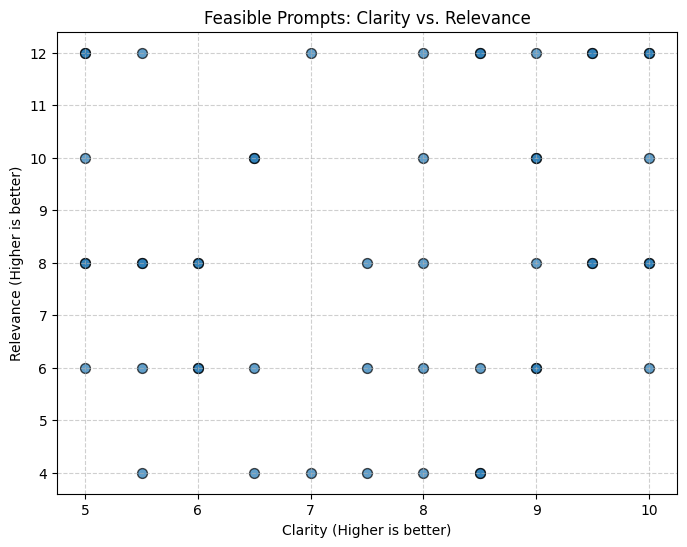

In [57]:
feasible_objectives = np.array([p.objectives for p in final_population if p.total_violation == 0])
if feasible_objectives.shape[0] > 0:
    plt.figure(figsize=(8, 6))
    plt.scatter(feasible_objectives[:, 0], feasible_objectives[:, 2], s=50, edgecolors='k', alpha=0.7)
    plt.title("Feasible Prompts: Clarity vs. Relevance")
    plt.xlabel("Clarity (Higher is better)")
    plt.ylabel("Relevance (Higher is better)")
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()
else:
    print("\nNo feasible prompts to plot.")